# Alright, let's extend this. The Extended Kalman Filter. HAHA get it?

You already have become an expert on Kalman Filters. It that scenario we assumed that the physics and sensor were linear model.  The question now is: what happens when the physics model or the sensor model isn't linear anymore?

A real sensor doesn't always hand you your state directly with a nice clean matrix. Radar, for example, gives you range, and range is a nonlinear function of position. Imagine we were on the ground and trying to move a gimbal to track the rocket as we go up. In the start we're slewing fast, but as the rocket climbs the gimbal needs to slew much slower. **This is a non-linear problem**

The Extended Kalman Filter (EKF) deals with this by linearizing around our current best estimate every single step using a Jacobian.

That's really all it is: the Kalman filter with a Jacobian sprinkled in. Same predict/update loop as before. 

# Wait what's a Jacobian? 

It's basically a matrix of a vector valued function's derivatives

1 input ($f(x_1)$): 

$J = \begin{bmatrix}
\frac{\partial f_1}{\partial x_1} \\
\end{bmatrix}$

Its just a derivative 

2 input ($f(x_1, x_2)$):

$J = \begin{bmatrix}
\frac{\partial f_1}{\partial x_1} & \frac{\partial f_1}{\partial x_2} \\
\frac{\partial f_2}{\partial x_1} & \frac{\partial f_2}{\partial x_2}
\end{bmatrix}$

3 input ($f(x_1, x_2, x_3)$):

$J = \begin{bmatrix}
\frac{\partial f_1}{\partial x_1} & \frac{\partial f_1}{\partial x_2} & \frac{\partial f_1}{\partial x_3} \\
\frac{\partial f_2}{\partial x_1} & \frac{\partial f_2}{\partial x_2} & \frac{\partial f_2}{\partial x_3} \\
\frac{\partial f_3}{\partial x_1} & \frac{\partial f_3}{\partial x_2} & \frac{\partial f_3}{\partial x_3}
\end{bmatrix}$



### The setup

I'm going to give a highly non-linear example to prove a point! Same rocket as before, going straight up with roughly constant velocity. But now instead of a sensor that reads altitude directly, we have a radar station sitting on the ground, a horizontal distance $d$ away from the launch pad. It measures the **slant range** to the rocket, not altitude. 

$r = \sqrt{d^2 + h^2}$ where $r$ is the slant range, $h$ is rocket height (from position) and $d$ is a known range from the rocket. 

See the problem? $h$ (altitude, which is part of our state) is stuck inside a square root. You can't apply the normal Kalman Filter since there is no constant matrix $H$ such that $r = Hx$. This is exactly why we need the Extended Kalman Filter.

So to visualize: 

![Alternative text](rocket_radar_matplotlib_visualization.png)



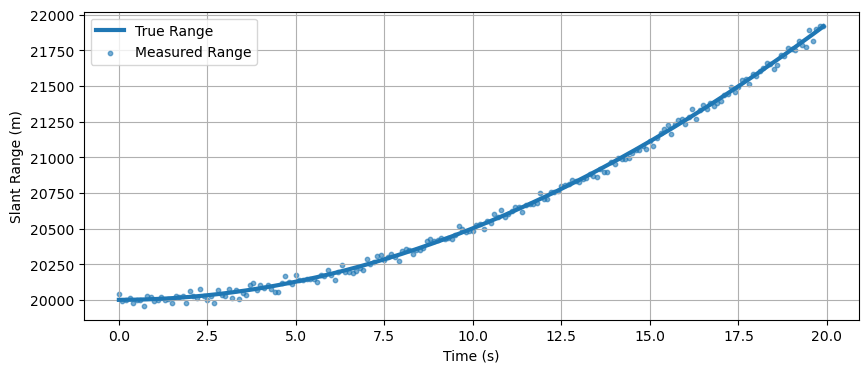

In [67]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

dt = 0.1
time = np.arange(0, 20, dt)

true_position = 10 + 450 * time 
d = 20000  # radar is 200m from the launch pad

true_range = np.sqrt(d**2 + true_position**2)
measured_range = true_range + np.random.normal(0, 25, len(time))

plt.figure(figsize=(10, 4))
plt.plot(time, true_range, label="True Range", linewidth=3)
plt.scatter(time, measured_range, s=10, alpha=0.6, label="Measured Range")
plt.xlabel("Time (s)")
plt.ylabel("Slant Range (m)")
plt.grid(True)
plt.legend()
plt.show()

Notice the range doesn't even look linear in time anymore, even though the rocket is just moving at constant velocity. That curve is the nonlinearity we have to deal with using the EKF.

### The EKF equations

Lets assume you know the Kalman Filter Equations! 

Our motion model is still linear (constant velocity), so the predict step doesn't change at all:

$x_{pred} = Fx$

$P_{pred} = FPF^T + Q$

The update step is where we change things. Instead of a constant matrix $H$, we now have a nonlinear function $h(x)$ that maps our state to what the sensor should read:

$h(x) = \sqrt{d^2 + x_0^2}$

where $x_0$ is position. One input only! 

Since we can't just multiply by $h(x)$, we linearize it around our predicted state using the Jacobian:

$H = \frac{\partial h}{\partial x}\Big|_{x_{pred}} = \begin{bmatrix} \frac{x_0}{\sqrt{d^2+x_0^2}} & 0 \end{bmatrix}$ 

The 0 is added since we only have a range measurement. We have no measurement of velocity, so we set it to 0. If we had doppler rates (also very non-linear) as used in traditional radar we would....but for the sake of simplicity lets ignore that for now! 

That's just the derivative of $h$ with respect to each state variable, evaluated wherever we currently think we are. This $H$ stands in for the constant $H$ we used in the regular Kalman Filter, except now it gets recomputed every iteration. Everything else in the update step looks the same as before, just swapping in $h(x_{pred})$ for the predicted measurement:

$y = z - h(x_{pred})$

$S = HP_{pred}H^T + R$

$K = P_{pred}H^TS^{-1}$

$x = x_{pred} + Ky$

$P = (I - KH)P_{pred}$

That's the whole trick of the EKF: keep every equation the same as the regular Kalman Filter, just recompute $H$ (and $F$ too, if your motion model is also nonlinear) at every step by taking the Jacobian at your current estimate. Done. Easy. 

Now in python....

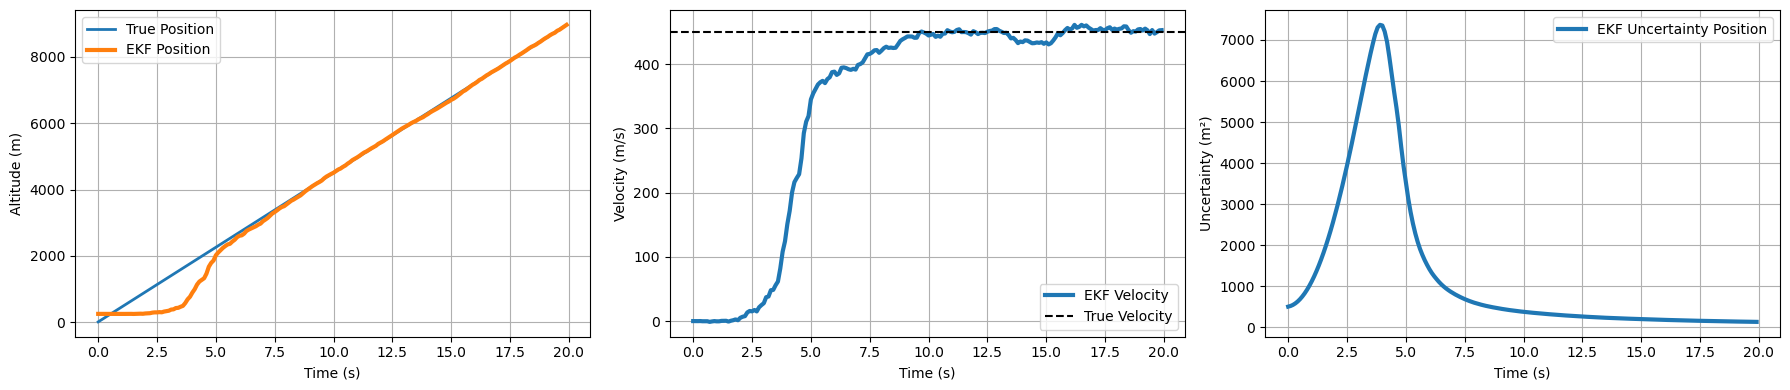

In [77]:
def h(x, d):
    return np.sqrt(d**2 + x[0, 0]**2)

def H_jacobian(x, d):
    px = x[0, 0]
    denom = np.sqrt(d**2 + px**2)
    return np.array([[px / denom, 0]])

def extended_kalman_filter(measurements, dt, d, measurement_std):
    states = []
    residuals = []
    uncertainty_P = []

    x = np.array([[250], [0]])  # initial state: position=1, velocity=0

    P = np.array([[500, 0],
                  [0, 500]])

    F = np.array([[1, dt],
                  [0, 1]])

    Q = np.array([[1, 0],
                  [0, 3]])

    R = np.array([[measurement_std**2]])

    I = np.eye(2)

    for z in measurements:
        # Predict (still linear, nothing new here)
        x_pred = F @ x
        P_pred = F @ P @ F.T + Q

        # Update (this is where the EKF actually differs)
        H = H_jacobian(x_pred, d)
        y = z - h(x_pred, d)
        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)
        x = x_pred + K * y
        P = (I - K @ H) @ P_pred

        states.append(x.flatten())
        residuals.append(y)
        uncertainty_P.append(P[0, 0].item())

    return np.array(states), np.array(residuals), np.array(uncertainty_P)

states, residuals, uncertainty_P = extended_kalman_filter(measured_range, dt, d, measurement_std=15)

estimated_position = states[:, 0]
estimated_velocity = states[:, 1]


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

ax1.plot(time, true_position, label="True Position", linewidth=2)
ax1.plot(time, estimated_position, label="EKF Position", linewidth=3)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Altitude (m)")
ax1.grid(True)
ax1.legend()

ax2.plot(time, estimated_velocity, label="EKF Velocity", linewidth=3)
ax2.axhline(450, color="black", linestyle="--", label="True Velocity")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Velocity (m/s)")
ax2.grid(True)
ax2.legend()

ax3.plot(time, uncertainty_P, label="EKF Uncertainty Position", linewidth=3)
ax3.set_xlabel("Time (s)")
ax3.set_ylabel("Uncertainty (m²)")
ax3.grid(True)
ax3.legend()


plt.tight_layout()
plt.show()

Even though the sensor never told us position directly, and the relationship between position and the measurement was nonlinear the whole time, the EKF still pulls out a solid position and velocity estimate. It just had to keep relinearizing at every step to do it.

Also notice how the filter doesn't converge right away. This is since its trying to filter out a bad initial estimate and over time locks in onto the true state. 

### 🎯 Your Turn

In the cell below, try:

- Making the radar closer to the pad (smaller $d$)
- Making the radar farther away (bigger $d$)
- Increasing `measurement_std`

Moving the radar changes the geometry, so regenerate `measured_range` from the new $d$ before you filter with it — the ranges the cell came with describe a station that is no longer there.

What happens to how well the filter tracks position and velocity? Does the filter struggle more when the radar is close or far?


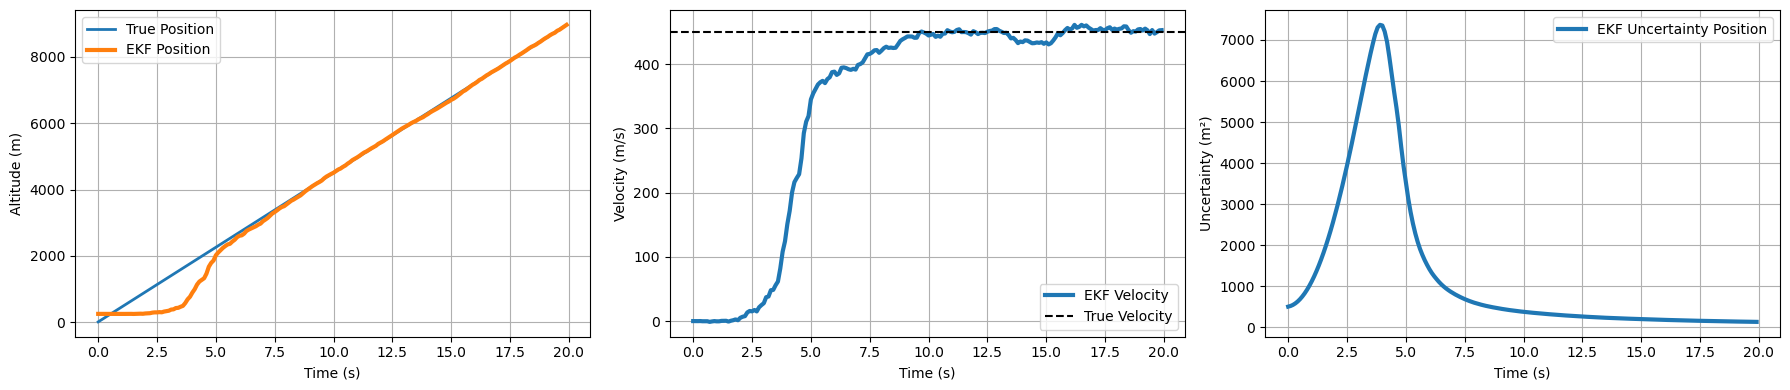

In [76]:
def h(x, d):
    return np.sqrt(d**2 + x[0, 0]**2)

def H_jacobian(x, d):
    px = x[0, 0]
    denom = np.sqrt(d**2 + px**2)
    return np.array([[px / denom, 0]])

def extended_kalman_filter(measurements, dt, d, measurement_std):
    states = []
    residuals = []
    uncertainty_P = []

    x = np.array([[250], [0]])  # initial state: position=1, velocity=0

    P = np.array([[500, 0],
                  [0, 500]])

    F = np.array([[1, dt],
                  [0, 1]])

    Q = np.array([[1, 0],
                  [0, 3]])

    R = np.array([[measurement_std**2]])

    I = np.eye(2)

    for z in measurements:
        # Predict (still linear, nothing new here)
        x_pred = F @ x
        P_pred = F @ P @ F.T + Q

        # Update (this is where the EKF actually differs)
        H = H_jacobian(x_pred, d)
        y = z - h(x_pred, d)
        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)
        x = x_pred + K * y
        P = (I - K @ H) @ P_pred

        states.append(x.flatten())
        residuals.append(y)
        uncertainty_P.append(P[0, 0].item())

    return np.array(states), np.array(residuals), np.array(uncertainty_P)

### BEGIN STUB
states, residuals, uncertainty_P = extended_kalman_filter(measured_range, dt, d, measurement_std=15)
### END STUB
### BEGIN SOLUTION
# Bring the radar in from 20 km to 4 km, and let the filter trust the range
# less than before. Moving the radar changes the geometry, so the slant
# ranges have to be generated again from the new distance -- the old ones
# describe a station that is no longer there.
radar_distance = 4000
close_range = (np.sqrt(radar_distance**2 + true_position**2)
               + np.random.normal(0, 25, len(time)))

states, residuals, uncertainty_P = extended_kalman_filter(
    close_range, dt, radar_distance, measurement_std=40)
### END SOLUTION

estimated_position = states[:, 0]
estimated_velocity = states[:, 1]


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

ax1.plot(time, true_position, label="True Position", linewidth=2)
ax1.plot(time, estimated_position, label="EKF Position", linewidth=3)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Altitude (m)")
ax1.grid(True)
ax1.legend()

ax2.plot(time, estimated_velocity, label="EKF Velocity", linewidth=3)
ax2.axhline(450, color="black", linestyle="--", label="True Velocity")
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Velocity (m/s)")
ax2.grid(True)
ax2.legend()

ax3.plot(time, uncertainty_P, label="EKF Uncertainty Position", linewidth=3)
ax3.set_xlabel("Time (s)")
ax3.set_ylabel("Uncertainty (m²)")
ax3.grid(True)
ax3.legend()


plt.tight_layout()
plt.show()

### 🚀 Challenge: Add a bearing measurement

Right now the radar only measures range. Real radars usually also measure the bearing angle $\theta$ to the target:

$\theta = \arctan\left(\frac{h}{d}\right)$

Your tasks:

- Extend the measurement vector to $z = \begin{bmatrix} r \\ \theta \end{bmatrix}$
- Extend $h(x)$ and $J(h(x))$ to output both equations (and both rows of the Jacobian)
- Re-run the EKF with both measurements and compare the estimate to the range-only version

Does adding the bearing measurement make the estimate better? Why do you think that is?

A few practical notes, so the two runs stay comparable:

- Give the two-row versions their **own names** (`h_rb` and `H_jacobian_rb`, say).
  If you redefine `h` and `H_jacobian`, the range-only filter from the cell above
  quietly starts using them too, and then there is nothing left to compare against.
- `R` is now **2x2** — one variance for the range, one for the bearing. Keep calling
  it `R`. They are in different units, so the two numbers are nowhere near the same
  size.
- Keep the bearing measurements in an array of their own, and keep the state history
  from each run, so you can plot the range-only and range+bearing position estimates
  against `true_position` on the same axes.


In [3]:
# Write your code here
#% checker: bearing_measurement
### BEGIN SOLUTION
# The radar now reports two things at once, so a measurement is a 2-vector:
# the slant range r, and the bearing angle theta = arctan(h / d).
bearing_std = 0.001   # radians, about 0.06 degrees -- a good radar
true_bearing = np.arctan(true_position / d)
measured_bearing = true_bearing + np.random.normal(0, bearing_std, len(time))

# One row per timestep: [range, bearing].
measured_z = np.column_stack([measured_range, measured_bearing])


def h_rb(x, d):
    """What the radar should read for state x: [range, bearing]."""
    px = x[0, 0]
    return np.array([[np.sqrt(d**2 + px**2)],
                     [np.arctan(px / d)]])


def H_jacobian_rb(x, d):
    """d(h)/d(x) -- one row per measurement, one column per state variable."""
    px = x[0, 0]
    denom = np.sqrt(d**2 + px**2)
    return np.array([[px / denom,          0.0],
                     [d / (d**2 + px**2),  0.0]])


def ekf_range_bearing(measurements, dt, d, range_std, bearing_std):
    states = []

    x = np.array([[250], [0]])
    P = np.array([[500, 0],
                  [0, 500]])
    F = np.array([[1, dt],
                  [0, 1]])
    Q = np.array([[1, 0],
                  [0, 3]])
    # Two measurements now, in completely different units: metres and radians.
    R = np.array([[range_std**2, 0],
                  [0, bearing_std**2]])
    I = np.eye(2)

    for row in measurements:
        z = np.array(row).reshape(2, 1)

        # Predict -- untouched, the motion model is still linear.
        x_pred = F @ x
        P_pred = F @ P @ F.T + Q

        # Update -- identical equations, just with a 2-row h and a 2-row H.
        H = H_jacobian_rb(x_pred, d)
        y = z - h_rb(x_pred, d)
        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)
        x = x_pred + K @ y
        P = (I - K @ H) @ P_pred

        states.append(x.flatten())

    return np.array(states)


states_both = ekf_range_bearing(measured_z, dt, d, 15, bearing_std)
states_range_only, _, _ = extended_kalman_filter(measured_range, dt, d, measurement_std=15)

rms_both = np.sqrt(np.mean((states_both[:, 0] - true_position) ** 2))
rms_range_only = np.sqrt(np.mean((states_range_only[:, 0] - true_position) ** 2))
print(f"Range only RMS position error:    {rms_range_only:8.2f} m")
print(f"Range + bearing RMS position error: {rms_both:8.2f} m")

plt.figure(figsize=(10, 4))
plt.plot(time, true_position, label="True Position", linewidth=3)
plt.plot(time, states_range_only[:, 0], label="EKF, range only", linewidth=2)
plt.plot(time, states_both[:, 0], label="EKF, range + bearing", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Altitude (m)")
plt.grid(True)
plt.legend()
plt.show()

# The bearing pins down altitude directly: near the pad the range barely moves
# when the rocket climbs (dr/dh = h/r is almost zero), so range alone is nearly
# blind early on, while the bearing is at its most sensitive exactly there.
### END SOLUTION


**Summary**

The Extended Kalman Filter is just the Kalman Filter with one change: whenever your model or your measurement function is nonlinear, you linearize it at every step using a Jacobian, then run the exact same predict/update equations.

- Predict step: unchanged if your motion model is linear, otherwise use the Jacobian of $f(x)$ for $F$. Same way we did it for $h(x)$. 
- Update step: replace $Hx_{pred}$ with $h(x_{pred})$, and replace $H$ with the Jacobian of $h(x)$ evaluated at $x_{pred}$
- Everything else is identical to the regular Kalman Filter!

The catch is that this linearization is only an approximation, and if the true system is highly nonlinear or your estimate is way off, that approximation can break down. That's the motivation for filters like the Unscented Kalman Filter...please don't make me explain that one tho 😭. 